# Spectral Analysis of the Glued Trees Quantum Walk

In [1]:
# Imports
import sys
from pathlib import Path

# Add the parent directory to the system path
glued_trees_path = Path.cwd().parent.__str__()
if glued_trees_path not in sys.path:
    sys.path.append(glued_trees_path)

from joblib import Parallel, delayed
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from tqdm import tqdm
from scipy.sparse.linalg import eigsh
from scipy.stats import norm, t

from qutip import *

from src.glued_trees.classes import *

In [2]:
# Initialize RNG seed for reproducibility
rng = np.random.default_rng(0)

In [3]:
# Set default plot parameters
plt.rcParams["font.size"] = 18
plt.rcParams["font.sans-serif"] = "Arial"
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"

## Single tree analysis

In [4]:
h = 8  # Tree height
J = -1  # Coupling strength
sigma = 0  # Disorder strength

gt = GluedTreesDisorder(h, J, sigma, distribution="uniform")
E, V = gt.compute_spectrum()

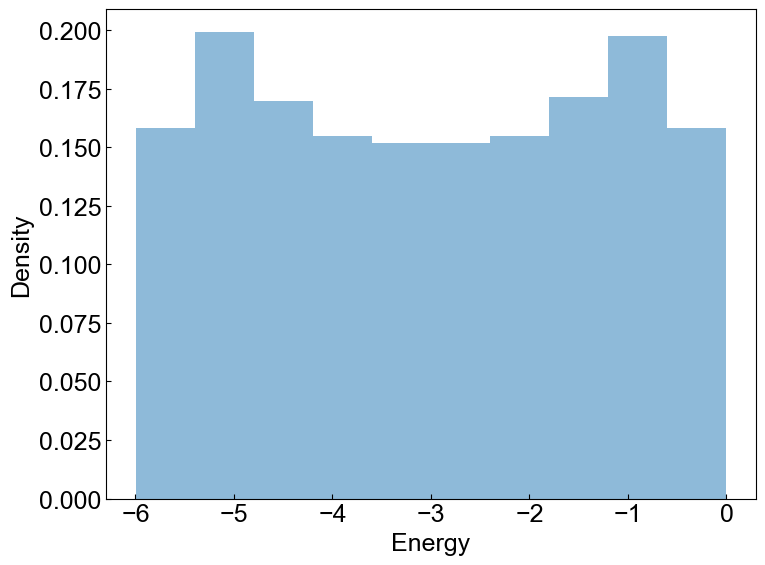

In [5]:
# Plot density of states
fig, ax = plt.subplots(1, 1, figsize=(8, 6), dpi=100)
ax.hist(E, bins=10, density=True, alpha=0.5)
ax.set_xlabel("Energy")
ax.set_ylabel("Density")
plt.tight_layout()
plt.show()

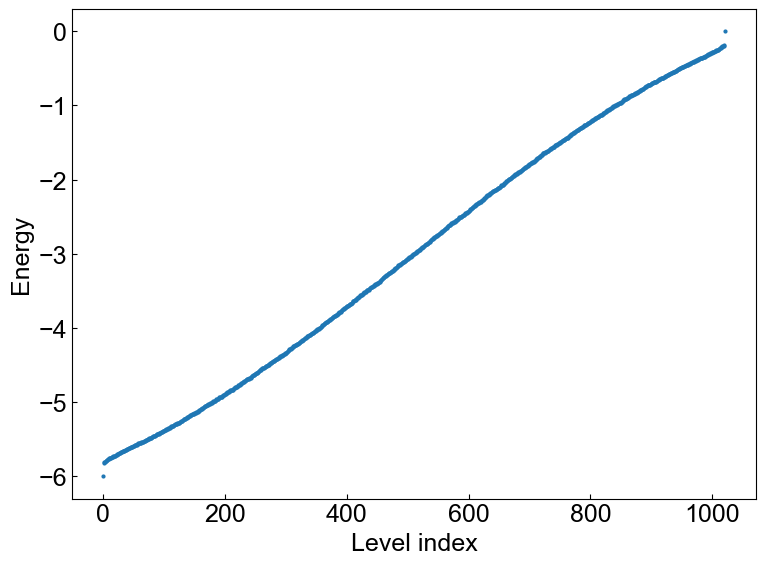

In [6]:
# Plot energy levels
fig, ax = plt.subplots(1, 1, figsize=(8, 6), dpi=100)
ax.plot(np.arange(len(E)), E, "o", markersize=2)
ax.set_xlabel("Level index")
ax.set_ylabel("Energy")
plt.tight_layout()
plt.show()

In [7]:
# Compute energy gap as a function of both disorder strength and tree height in parallel
# hs = [4, 5, 6, 7, 8, 9, 10, 11, 12]
hs = [4, 5, 6, 7, 8]
sigmas = np.logspace(-2, 2, 21)

def compute_gap(h, sigma, realizations=100):
    gaps = []
    for i in range(realizations):
        gt = GluedTreesDisorder(h, J, sigma, distribution="uniform", rng=i)
        E, _ = eigsh(gt.get_hamiltonian(sparse=True), k=2, which="SA")
        gaps.append(E[1] - E[0])
    return np.mean(gaps)

results = Parallel(n_jobs=-1, verbose=20)(
    delayed(compute_gap)(h, sigma) for h in hs for sigma in sigmas
)

gaps = np.array(results).reshape(len(hs), len(sigmas))

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:   45.3s
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:   45.5s
[Parallel(n_jobs=-1)]: Done   3 tasks      | elapsed:   45.6s
[Parallel(n_jobs=-1)]: Done   4 tasks      | elapsed:   47.3s
[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:   47.5s
[Parallel(n_jobs=-1)]: Done   6 tasks      | elapsed:   48.3s
[Parallel(n_jobs=-1)]: Done   7 tasks      | elapsed:   48.4s
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:   50.0s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:   50.9s
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:   51.0s
[Parallel(n_jobs=-1)]: Done  11 tasks      | elapsed:   51.8s
[Parallel(n_jobs=-1)]: Done  12 tasks      | elapsed:   51.9s
[Parallel(n_jobs=-1)]: Done  13 tasks      | elapsed:   53.2s
[Parallel(n_jobs=-1)]: Done  14 tasks      | elapsed:   55.6s
[Parallel(n_jobs=-1)]: Done  15 tasks      | elapsed:   

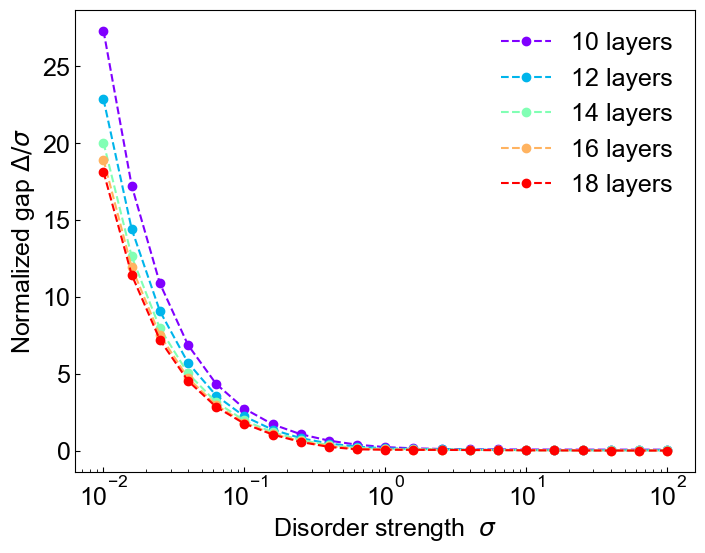

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6), dpi=100)
cmap = plt.get_cmap("rainbow")
for i, h in enumerate(hs):
    ax.plot(sigmas, gaps[i] / sigmas, label=f"{2 * h + 2} layers", linestyle="--", marker="o", color=cmap(i / (len(hs) - 1)))
ax.set_xscale("log")
# ax.set_yscale("log")
ax.set_xlabel(r"Disorder strength  $\sigma$")
ax.set_ylabel(r"Normalized gap $\Delta/\sigma$")
ax.legend(frameon=False)
plt.show()

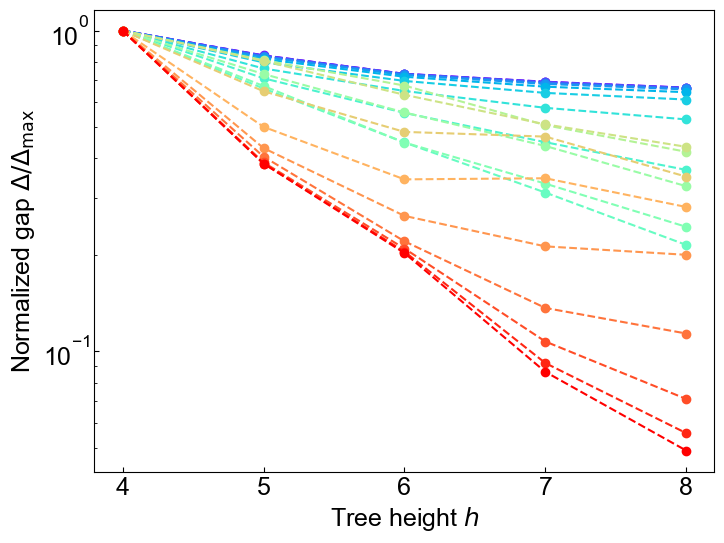

In [9]:
# Plot now gap as a function of number of layers for multiple disorder strengths
fig, ax = plt.subplots(1, 1, figsize=(8, 6), dpi=100)
cmap = plt.get_cmap("rainbow")
for i, sigma in enumerate(sigmas):
    ax.plot(hs, gaps[:, i] / gaps[0, i], label=f"$\\sigma={sigma}$", linestyle="--", marker="o", color=cmap(i / (len(sigmas) - 1)))
# ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Tree height $h$")
ax.set_ylabel(r"Normalized gap $\Delta/\Delta_{\mathrm{max}}$")
# ax.legend(frameon=False)
plt.show()

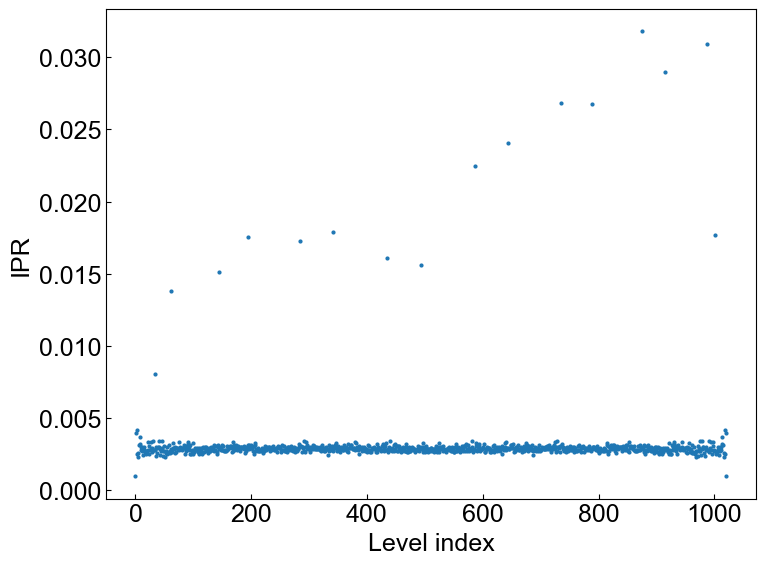

In [10]:
# Plot the Inverse Participation Ratio (IPR) of the eigenstates
ipr = np.sum(np.abs(V) ** 4, axis=0)

fig, ax = plt.subplots(1, 1, figsize=(8, 6), dpi=100)
ax.plot(np.arange(len(E)), ipr, "o", markersize=2)
ax.set_xlabel("Level index")
ax.set_ylabel("IPR")
plt.tight_layout()
plt.show()

## Spectral properties as a function of disorder strength

In [11]:
h = 5  # Tree height
J = -1  # Coupling strength

sigmas = np.logspace(-2, 2, 101)  # Disorder strength

# Compute phase coherence of first eigenstate and Inverse Participation Ratio (IPR)


def compute_phase_coherence(gt, V):
    coherence = 0
    for layer_idx in range(2 * h + 2):
        start_idx, end_idx = gt._layer_indices(layer_idx)
        coherence += np.abs(np.sum(V[start_idx:end_idx, 0]))
    coherence /= np.sqrt(gt.N)
    return coherence


def compute_ipr(V):
    ipr = np.sum(np.abs(V) ** 4, axis=0)
    return ipr


def compute_coherence_and_ipr(sigma, realizations=10):
    cohs = []
    iprs = []

    # Compute phase coherence and IPR for multiple realizations
    for i in range(realizations):
        gt = GluedTreesDisorder(h, J, sigma, distribution="uniform", rng=i)
        E, V = gt.compute_spectrum()
        cohs.append(compute_phase_coherence(gt, V))
        iprs.append(np.min(compute_ipr(V)))

    # Compute statistics (mean and 95% CI)
    c = t.ppf(0.975, realizations - 1)  # 97.5%-th percentile for 95% CI

    mean_coh = np.mean(cohs)
    std_coh = np.std(cohs)
    res_coh = {
        "mean": mean_coh,
        "ci95": [mean_coh - c * std_coh / np.sqrt(realizations),
                 mean_coh + c * std_coh / np.sqrt(realizations)],
    }

    mean_ipr = np.mean(iprs)
    std_ipr = np.std(iprs)
    res_ipr = {
        "mean": mean_ipr,
        "ci95": [mean_ipr - c * std_ipr / np.sqrt(realizations),
                 mean_ipr + c * std_ipr / np.sqrt(realizations)],
    }

    return res_coh, res_ipr


res = Parallel(n_jobs=-1, verbose=10)(
    delayed(compute_coherence_and_ipr)(sigma, realizations=100) for sigma in sigmas)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    7.9s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:   11.9s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:   16.9s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:   23.3s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   28.5s
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:   35.7s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:   43.8s
[Parallel(n_jobs=-1)]: Done  69 tasks      | elapsed:   50.6s
[Parallel(n_jobs=-1)]: Done  82 tasks      | elapsed:  1.0min
[Parallel(n_jobs=-1)]: Done  97 out of 101 | elapsed:  1.2min remaining:    2.8s
[Parallel(n_jobs=-1)]: Done 101 out of 101 | elapsed:  1.2min finished


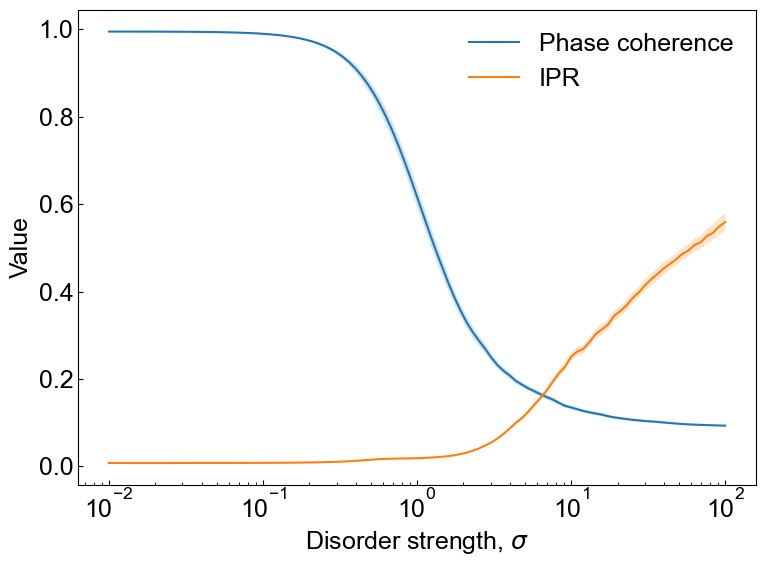

In [12]:
# Plot coherence and IPR vs. disorder strength
fig, ax = plt.subplots(1, 1, figsize=(8, 6), dpi=100)

ax.plot(sigmas, [r[0]["mean"] for r in res], label="Phase coherence")
ax.fill_between(sigmas, 
                [r[0]["ci95"][0] for r in res], 
                [r[0]["ci95"][1] for r in res], 
                alpha=0.2)

ax.plot(sigmas, [r[1]["mean"] for r in res], label="IPR")
ax.fill_between(sigmas, 
                [r[1]["ci95"][0] for r in res], 
                [r[1]["ci95"][1] for r in res], 
                alpha=0.2)

ax.set_xscale("log")
ax.set_xlabel(r"Disorder strength, $\sigma$")
ax.set_ylabel("Value")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## Time-averaged exit probability in all-to-all model

In [13]:
def compute_exit_probability(sigma, J2, realizations=10):
    # Compute exit probability for multiple realizations
    ps = []

    for i in range(realizations):
        gt = GluedTreesAllToAll(h, J, J2, sigma, distribution="uniform", rng=i)
        ps.append(gt.average_layer_distribution()[-1])

    # Compute statistics (mean and 95% CI)
    c = t.ppf(0.975, realizations - 1)  # 97.5%-th percentile for 95% CI

    mean_p = np.mean(ps)
    std_p = np.std(ps)
    res_p = {
        "mean": mean_p,
        "ci95": [mean_p - c * std_p / np.sqrt(realizations),
                 mean_p + c * std_p / np.sqrt(realizations)],
    }

    return res_p

In [14]:
h = 5  # Tree height
J = -1  # Coupling strength
J2s = np.linspace(0, 20, 21)  # Intra-layer coupling strength
sigmas = [0, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1, 2, 5, 10]  # Disorder strength

# Compute exit probability for the case of no disorder
gt = GluedTreesAllToAll(h, J, 0, 0, distribution="uniform")
p0 = gt.average_layer_distribution()[-1]

# Compute exit probability for different disorder strengths and intra-layer couplings
res = Parallel(n_jobs=-1, verbose=20)(
    delayed(compute_exit_probability)(sigma, J2, realizations=100) for J2 in J2s for sigma in sigmas)
res = np.array(res).reshape(len(J2s), len(sigmas))

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    8.6s
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    8.6s
[Parallel(n_jobs=-1)]: Done   3 tasks      | elapsed:    8.8s
[Parallel(n_jobs=-1)]: Done   4 tasks      | elapsed:    8.9s
[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:    9.3s
[Parallel(n_jobs=-1)]: Done   6 tasks      | elapsed:   10.3s
[Parallel(n_jobs=-1)]: Done   7 tasks      | elapsed:   12.4s
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:   12.6s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:   17.2s
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:   17.6s
[Parallel(n_jobs=-1)]: Done  11 tasks      | elapsed:   18.1s
[Parallel(n_jobs=-1)]: Done  12 tasks      | elapsed:   19.1s
[Parallel(n_jobs=-1)]: Done  13 tasks      | elapsed:   19.4s
[Parallel(n_jobs=-1)]: Done  14 tasks      | elapsed:   19.9s
[Parallel(n_jobs=-1)]: Done  15 tasks      | elapsed:   21.4s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:   22.1s
[Paralle

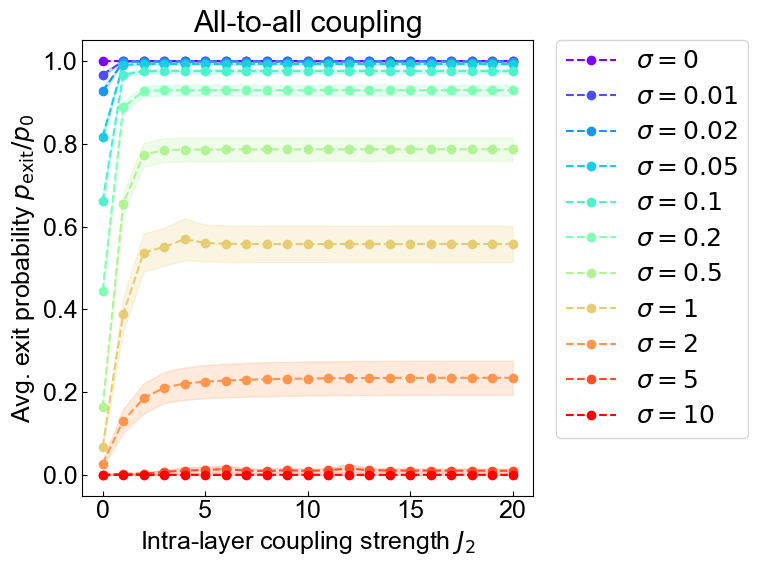

In [15]:
# Visualize results
cmap = plt.get_cmap("rainbow")

fig, ax = plt.subplots(1, 1, figsize=(8, 6), dpi=100)
for i, sigma in enumerate(sigmas):
    means = [r["mean"] / p0 for r in res[:, i]]
    ci95_lower = [r["ci95"][0] / p0 for r in res[:, i]]
    ci95_upper = [r["ci95"][1] / p0 for r in res[:, i]]

    ax.plot(J2s, means, label=f"$\\sigma={sigma}$", linestyle="--", marker="o", color=cmap(i / (len(sigmas) - 1)))
    ax.fill_between(J2s, ci95_lower, ci95_upper, alpha=0.2, color=cmap(i / (len(sigmas) - 1)))

# ax.set_xscale("log")
ax.set_xlabel("Intra-layer coupling strength $J_2$")
ax.set_ylabel(r"Avg. exit probability $p_{\text{exit}}/p_0$")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0.)
ax.set_title("All-to-all coupling")
plt.tight_layout()
plt.show()

In [24]:
# Compute exit probability for an isanely large value of J2
h = 7  # Tree height
J = -1  # Coupling strength
J2s = [0, 1e9]  # Intra-layer coupling strength
sigmas = np.logspace(-2, 2, 101)  # Disorder strength

# Compute exit probability for the case of no disorder
gt = GluedTreesAllToAll(h, J, J2s[0], 0, distribution="uniform")
p0 = gt.average_layer_distribution()[-1]

res = Parallel(n_jobs=-1, verbose=10)(
    delayed(compute_exit_probability)(sigma, J2, realizations=10) for sigma in sigmas for J2 in J2s)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:   11.6s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:   22.6s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:   34.0s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:   46.8s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:  1.0min
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done  69 tasks      | elapsed:  1.8min
[Parallel(n_jobs=-1)]: Done  82 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done  97 tasks      | elapsed:  2.5min
[Parallel(n_jobs=-1)]: Done 112 tasks      | elapsed:  2.8min
[Parallel(n_jobs=-1)]: Done 129 tasks      | elapsed:  3.2min
[Parallel(n_jobs=-1)]: Done 146 tasks      | elapsed:  3.6min
[Parallel(n_jobs=-1)]: Done 165 tasks      | elapsed:  4.1min
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:  4

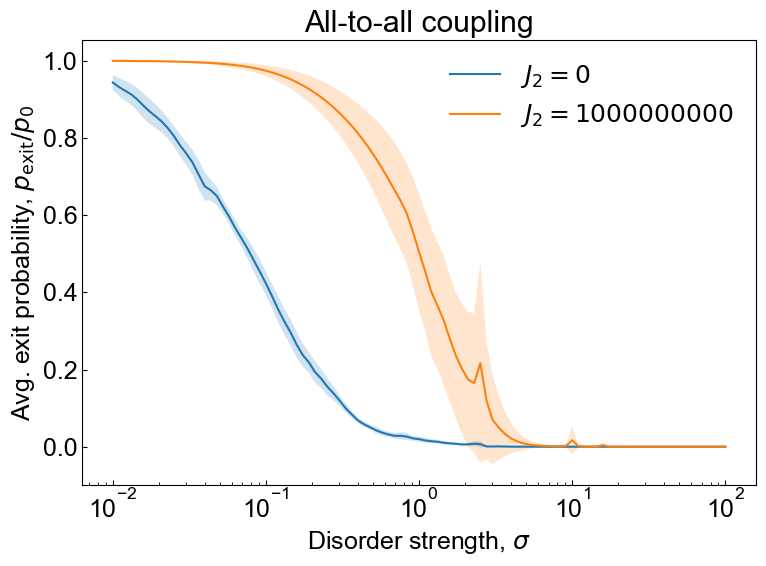

In [25]:
# Visualize results
fig, ax = plt.subplots(1, 1, figsize=(8, 6), dpi=100)
for i, J2 in enumerate(J2s):
    means = [r["mean"] / p0 for r in res[i::len(J2s)]]
    ci95_lower = [r["ci95"][0] / p0 for r in res[i::len(J2s)]]
    ci95_upper = [r["ci95"][1] / p0 for r in res[i::len(J2s)]]

    ax.plot(sigmas, means, label=f"$J_2={J2:.0f}$")
    ax.fill_between(sigmas, ci95_lower, ci95_upper, alpha=0.2)
ax.set_xscale("log")
ax.set_xlabel(r"Disorder strength, $\sigma$")
ax.set_ylabel(r"Avg. exit probability, $p_{\text{exit}}/p_0$")
ax.legend(frameon=False, loc="upper right")
ax.set_title("All-to-all coupling")
plt.tight_layout()
plt.show()

In [21]:
gt = GluedTreesAllToAll(h, J, J2=3, sigma=1, distribution="uniform")
H = gt.get_hamiltonian()